### 练习：验证万能近似定理

width=30: 100%|██████████| 2000/2000 [00:19<00:00, 101.35it/s]


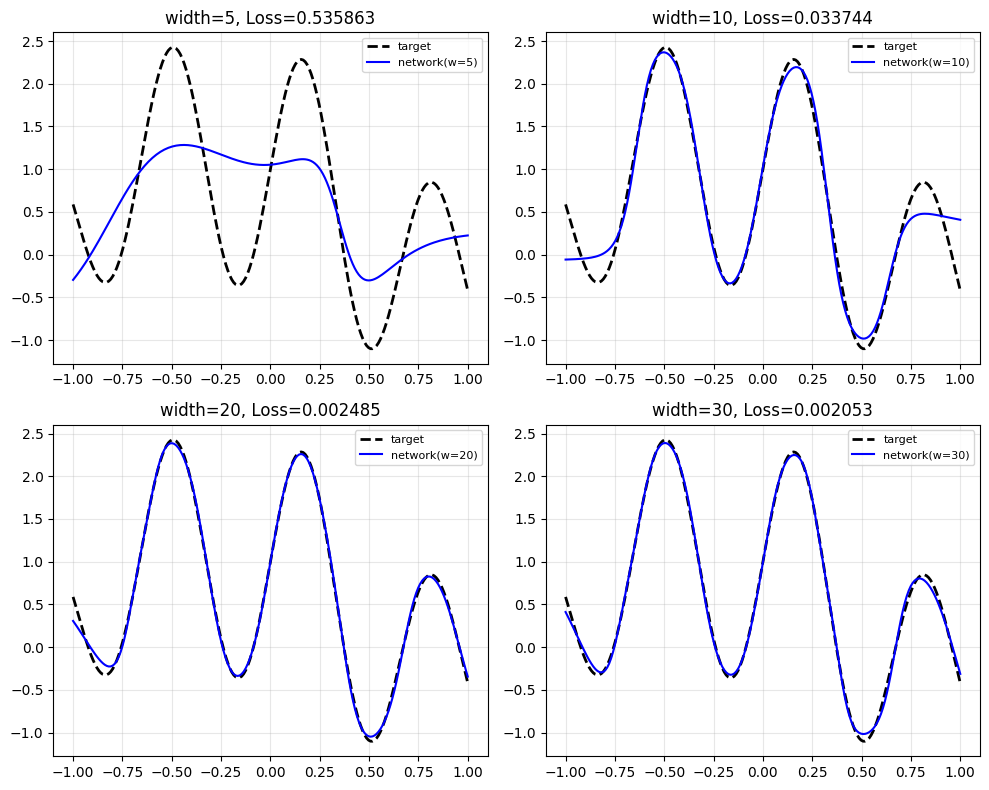

In [21]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# 目标函数：一个复杂的非线性函数
def target(x):
    return torch.sin(3*x) * torch.cos(5*x) + torch.sin(10*x) + torch.cos(2*x) + 0.5*x**2

# 设置随机种子以确保结果可复现
torch.manual_seed(42)
np.random.seed(42)


# 不同宽度的网络
widths = [5, 10, 20, 30]
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for i, w in enumerate(widths):
    model = nn.Sequential(
        nn.Linear(1, w), nn.Tanh(),
        nn.Linear(w, w), nn.Tanh(),
        nn.Linear(w, 1)
    )

    # 简单训练
    x = torch.linspace(-1, 1, 200).unsqueeze(1)
    y = target(x)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)

    iter = tqdm(range(2000), desc=f'width={w:02d}')
    for _ in iter:
        opt.zero_grad()
        loss = torch.mean((model(x) - y)**2)
        loss.backward()
        opt.step()

    ax = axes[i//2, i % 2]
    ax.plot(x.detach(), y.detach(), 'k--', label='target', linewidth=2)
    ax.plot(x.detach(), model(x).detach(), 'b-', label=f'network(w={w})')
    ax.set_title(f'width={w}, Loss={loss.item():.6f}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()